In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input
from tensorflow.keras.applications import MobileNetV2

import numpy as np
import matplotlib.pyplot as plt
import os
import urllib.request
import tarfile

In [2]:
# Descargar dataset
url = "http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar"
urllib.request.urlretrieve(url, "images.tar")

print("Descarga completa")

# Extraer dataset
with tarfile.open("images.tar") as tar:
    tar.extractall()

print("Extracción completa")

# Ruta del dataset
data_dir = "Images"

# Cargar dataset (con tamaño optimizado)
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

# ✅ Guardar nombres de clases ANTES de transformar
class_names = train_ds.class_names

# 🔥 Normalización (MUY IMPORTANTE)
train_ds = train_ds.map(lambda x, y: (x / 255.0, y))
val_ds = val_ds.map(lambda x, y: (x / 255.0, y))

# Mostrar información
print("Clases:", class_names)

for images, labels in train_ds:
    print("Shape imágenes:", images.shape)
    print("Shape labels:", labels.shape)
    break

Descarga completa


/tmp/ipykernel_15991/3619050350.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


Extracción completa
Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.
Clases: ['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu', 'n02086646-Blenheim_spaniel', 'n02086910-papillon', 'n02087046-toy_terrier', 'n02087394-Rhodesian_ridgeback', 'n02088094-Afghan_hound', 'n02088238-basset', 'n02088364-beagle', 'n02088466-bloodhound', 'n02088632-bluetick', 'n02089078-black-and-tan_coonhound', 'n02089867-Walker_hound', 'n02089973-English_foxhound', 'n02090379-redbone', 'n02090622-borzoi', 'n02090721-Irish_wolfhound', 'n02091032-Italian_greyhound', 'n02091134-whippet', 'n02091244-Ibizan_hound', 'n02091467-Norwegian_elkhound', 'n02091635-otterhound', 'n02091831-Saluki', 'n02092002-Scottish_deerhound', 'n02092339-Weimaraner', 'n02093256-Staffordshire_bullterrier', 'n02093428-American_Staffordshire_terrier', 'n02093647-Bedling

In [3]:
# Ruta del dataset
data_dir = "Images"

# Cargar dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

# Mostrar clases
print("Clases:", train_ds.class_names)

# Shapes
for images, labels in train_ds:
    print("Shape de imágenes de entrenamiento:", images.shape)
    print("Shape de etiquetas de entrenamiento:", labels.shape)
    break

for images, labels in val_ds:
    print("Shape de imágenes de validación:", images.shape)
    print("Shape de etiquetas de validación:", labels.shape)
    break

Found 20580 files belonging to 120 classes.
Using 16464 files for training.
Found 20580 files belonging to 120 classes.
Using 4116 files for validation.
Clases: ['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu', 'n02086646-Blenheim_spaniel', 'n02086910-papillon', 'n02087046-toy_terrier', 'n02087394-Rhodesian_ridgeback', 'n02088094-Afghan_hound', 'n02088238-basset', 'n02088364-beagle', 'n02088466-bloodhound', 'n02088632-bluetick', 'n02089078-black-and-tan_coonhound', 'n02089867-Walker_hound', 'n02089973-English_foxhound', 'n02090379-redbone', 'n02090622-borzoi', 'n02090721-Irish_wolfhound', 'n02091032-Italian_greyhound', 'n02091134-whippet', 'n02091244-Ibizan_hound', 'n02091467-Norwegian_elkhound', 'n02091635-otterhound', 'n02091831-Saluki', 'n02092002-Scottish_deerhound', 'n02092339-Weimaraner', 'n02093256-Staffordshire_bullterrier', 'n02093428-American_Staffordshire_terrier', 'n02093647-Bedlington_terrier', 'n0209

In [4]:
# Obtener un batch del dataset
for images, labels in train_ds:
    primera_imagen = images[0]

    print("Shape de la primera imagen:", primera_imagen.shape)
    print("Número total de píxeles:", tf.size(primera_imagen))

    break

Shape de la primera imagen: (128, 128, 3)
Número total de píxeles: tf.Tensor(49152, shape=(), dtype=int32)


In [5]:
for images, labels in train_ds:
    print("Etiqueta de la primera imagen:", labels[0])
    break

Etiqueta de la primera imagen: tf.Tensor(66, shape=(), dtype=int32)


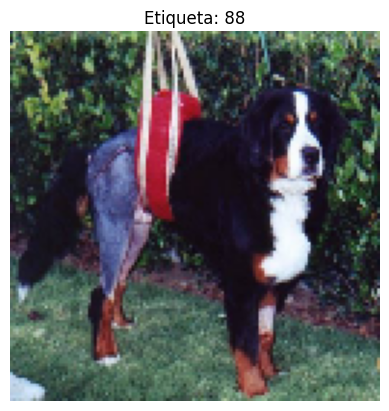

In [6]:
for images, labels in train_ds:
    plt.imshow(images[0].numpy().astype("uint8"))
    plt.title(f"Etiqueta: {labels[0]}")
    plt.axis('off')
    plt.show()
    break

In [7]:
# Número de clases
num_clases = len(train_ds.class_names)

print("Clases:", train_ds.class_names)
print("Número de clases:", num_clases)

Clases: ['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu', 'n02086646-Blenheim_spaniel', 'n02086910-papillon', 'n02087046-toy_terrier', 'n02087394-Rhodesian_ridgeback', 'n02088094-Afghan_hound', 'n02088238-basset', 'n02088364-beagle', 'n02088466-bloodhound', 'n02088632-bluetick', 'n02089078-black-and-tan_coonhound', 'n02089867-Walker_hound', 'n02089973-English_foxhound', 'n02090379-redbone', 'n02090622-borzoi', 'n02090721-Irish_wolfhound', 'n02091032-Italian_greyhound', 'n02091134-whippet', 'n02091244-Ibizan_hound', 'n02091467-Norwegian_elkhound', 'n02091635-otterhound', 'n02091831-Saluki', 'n02092002-Scottish_deerhound', 'n02092339-Weimaraner', 'n02093256-Staffordshire_bullterrier', 'n02093428-American_Staffordshire_terrier', 'n02093647-Bedlington_terrier', 'n02093754-Border_terrier', 'n02093859-Kerry_blue_terrier', 'n02093991-Irish_terrier', 'n02094114-Norfolk_terrier', 'n02094258-Norwich_terrier', 'n02094433-Yor

In [8]:
# -----------------------
# MODELO CNN OPTIMIZADO
# -----------------------
num_clases = len(class_names)  # Asegúrate de definir class_names después de cargar el dataset

model = models.Sequential()

# Bloque 1: Conv + MaxPooling
model.add(layers.Conv2D(64, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(layers.MaxPooling2D((2,2)))

# Bloque 2: Conv + MaxPooling
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Bloque 3: Conv + MaxPooling
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

# Flatten para pasar a fully connected
model.add(layers.Flatten())

# Fully Connected Layers (densas)
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(128, activation='relu'))

# Capa de salida con softmax para clasificación
model.add(layers.Dense(num_clases, activation='softmax'))

# Mostrar resumen del modelo
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 120)            │        15,480 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,694,392 (25.54 MB)

 Trainable params: 6,694,392 (25.54 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 35s 55ms/step - accuracy: 0.0123 - loss: 5.2853 - val_accuracy: 0.0104 - val_loss: 4.7843
Epoch 2/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - accuracy: 0.0131 - loss: 4.7887 - val_accuracy: 0.0100 - val_loss: 4.7836
Epoch 3/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.0149 - loss: 4.7760 - val_accuracy: 0.0097 - val_loss: 4.7844
Epoch 4/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 24s 47ms/step - accuracy: 0.0180 - loss: 4.7654 - val_accuracy: 0.0104 - val_loss: 4.7926
Epoch 5/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - accuracy: 0.0282 - loss: 4.7006 - val_accuracy: 0.0102 - val_loss: 4.8323
Epoch 6/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - accuracy: 0.0463 - loss: 4.6089 - val_accuracy: 0.0114 - val_loss: 5.0328
Epoch 7/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - accuracy: 0.0685 - loss: 4.4756 - val_accuracy: 0.0075 - val_loss: 5.0946
Epoch 8/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 39s 45ms/step - accuracy: 0.0904 - loss: 4.3519 - 

In [11]:
model.save('modelo_perros_stanford.keras')

In [ ]:
labels = train_ds.class_names

with open("labels.txt", "w") as f:
    for label in labels:
        f.write(label + "\n")
    print("Labels:", labels)

Labels: ['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu', 'n02086646-Blenheim_spaniel', 'n02086910-papillon', 'n02087046-toy_terrier', 'n02087394-Rhodesian_ridgeback', 'n02088094-Afghan_hound', 'n02088238-basset', 'n02088364-beagle', 'n02088466-bloodhound', 'n02088632-bluetick', 'n02089078-black-and-tan_coonhound', 'n02089867-Walker_hound', 'n02089973-English_foxhound', 'n02090379-redbone', 'n02090622-borzoi', 'n02090721-Irish_wolfhound', 'n02091032-Italian_greyhound', 'n02091134-whippet', 'n02091244-Ibizan_hound', 'n02091467-Norwegian_elkhound', 'n02091635-otterhound', 'n02091831-Saluki', 'n02092002-Scottish_deerhound', 'n02092339-Weimaraner', 'n02093256-Staffordshire_bullterrier', 'n02093428-American_Staffordshire_terrier', 'n02093647-Bedlington_terrier', 'n02093754-Border_terrier', 'n02093859-Kerry_blue_terrier', 'n02093991-Irish_terrier', 'n02094114-Norfolk_terrier', 'n02094258-Norwich_terrier', 'n02094433-Yor